In [3]:
import pandas as pd
from plotnine import *

In [4]:
avocado = pd.read_csv("C:/Users/USER/Downloads/avocado.csv")
avocado.head(20)
# Check all column names
avocado = avocado.drop(columns=['Unnamed: 0']) # dropping this column because it wont be needed


In [5]:
avocado.info()
avocado.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18249 non-null  object 
 1   AveragePrice  18249 non-null  float64
 2   Total Volume  18249 non-null  float64
 3   4046          18249 non-null  float64
 4   4225          18249 non-null  float64
 5   4770          18249 non-null  float64
 6   Total Bags    18249 non-null  float64
 7   Small Bags    18249 non-null  float64
 8   Large Bags    18249 non-null  float64
 9   XLarge Bags   18249 non-null  float64
 10  type          18249 non-null  object 
 11  year          18249 non-null  int64  
 12  region        18249 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 1.8+ MB


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [6]:
#  data preparation process
# let us convert to datetime
avocado['Date'] = pd.to_datetime(avocado['Date'])

# Verify
print(avocado['Date'].dtype) 


datetime64[ns]


In [7]:
#extracting features like month and year
avocado['year'] = avocado['Date'].dt.year
avocado['month'] = avocado['Date'].dt.month
avocado.head(10)

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11
5,2015-11-22,1.26,55979.78,1184.27,48067.99,43.61,6683.91,6556.47,127.44,0.0,conventional,2015,Albany,11
6,2015-11-15,0.99,83453.76,1368.92,73672.72,93.26,8318.86,8196.81,122.05,0.0,conventional,2015,Albany,11
7,2015-11-08,0.98,109428.33,703.75,101815.36,80.00,6829.22,6266.85,562.37,0.0,conventional,2015,Albany,11
8,2015-11-01,1.02,99811.42,1022.15,87315.57,85.34,11388.36,11104.53,283.83,0.0,conventional,2015,Albany,11
9,2015-10-25,1.07,74338.76,842.40,64757.44,113.00,8625.92,8061.47,564.45,0.0,conventional,2015,Albany,10


In [8]:
# missing values
avocado.isnull()
avocado.isnull().sum()
# no missing values

avocado.duplicated().sum()
# checking for duplicate rows

avocado2 = avocado.copy()
avocado2.columns = avocado2.columns.str.lower().str.replace (' ', '_')


In [9]:
avocado2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          18249 non-null  datetime64[ns]
 1   averageprice  18249 non-null  float64       
 2   total_volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   total_bags    18249 non-null  float64       
 7   small_bags    18249 non-null  float64       
 8   large_bags    18249 non-null  float64       
 9   xlarge_bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int32         
 12  region        18249 non-null  object        
 13  month         18249 non-null  int32         
dtypes: datetime64[ns](1), float64(9), int32(2), object(2)
memory usage: 1.8+ MB


In [10]:

avocado2.describe()
avocado2.describe(include=[float, int]) # i did not want the datetime column to show here
# looking at the mean and median, we can see that the data is skewed

,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899,6.177215
std,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938,3.534130
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000,1.000000
25%,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000,3.000000
50%,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000,6.000000
75%,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000,9.000000
max,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000,12.000000


In [11]:
avocado2.skew(numeric_only = True)
# checking how skewed it is

averageprice     0.580303
total_volume     9.007687
4046             8.648220
4225             8.942466
4770            10.159396
total_bags       9.756072
small_bags       9.540660
large_bags       9.796455
xlarge_bags     13.139751
year             0.215339
month            0.106617
dtype: float64

In [12]:
# checking the correlation for numeric variables
avocado_corr = avocado2.select_dtypes(include='number').corr()
avocado_corr
# Volume vs Categories (PLU Codes) strong positive correlation
# also strong positive correlation between the 3 categories (4046, 4225, 4770)
# Type vs Volume & Categories has a negative correlation
# total bags and small bags has a  very strong positive correlation with volume (multicollinearity)
# shows a negative correlation between volume and price (-0.19). 
# Specifically, 4046 (Small/Medium) has a slightly stronger negative correlation (-0.21) with price than the larger sizes,
# this suggests the market is most sensitive to a surplus of smaller fruit.


,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year,month
averageprice,1.000000,-0.192752,-0.208317,-0.172928,-0.179446,-0.177088,-0.174730,-0.172940,-0.117592,0.093197,0.162409
total_volume,-0.192752,1.000000,0.977863,0.974181,0.872202,0.963047,0.967238,0.880640,0.747157,0.017193,-0.024689
4046,-0.208317,0.977863,1.000000,0.926110,0.833389,0.920057,0.925280,0.838645,0.699377,0.003353,-0.025803
4225,-0.172928,0.974181,0.926110,1.000000,0.887855,0.905787,0.916031,0.810015,0.688809,-0.009559,-0.022108
4770,-0.179446,0.872202,0.833389,0.887855,1.000000,0.792314,0.802733,0.698471,0.679861,-0.036531,-0.033424
total_bags,-0.177088,0.963047,0.920057,0.905787,0.792314,1.000000,0.994335,0.943009,0.804233,0.071552,-0.022724
small_bags,-0.174730,0.967238,0.925280,0.916031,0.802733,0.994335,1.000000,0.902589,0.806845,0.063915,-0.023126
large_bags,-0.172940,0.880640,0.838645,0.810015,0.698471,0.943009,0.902589,1.000000,0.710858,0.087891,-0.020187
xlarge_bags,-0.117592,0.747157,0.699377,0.688809,0.679861,0.804233,0.806845,0.710858,1.000000,0.081033,-0.012969
year,0.093197,0.017193,0.003353,-0.009559,-0.036531,0.071552,0.063915,0.087891,0.081033,1.000000,-0.177050


<Axes: >

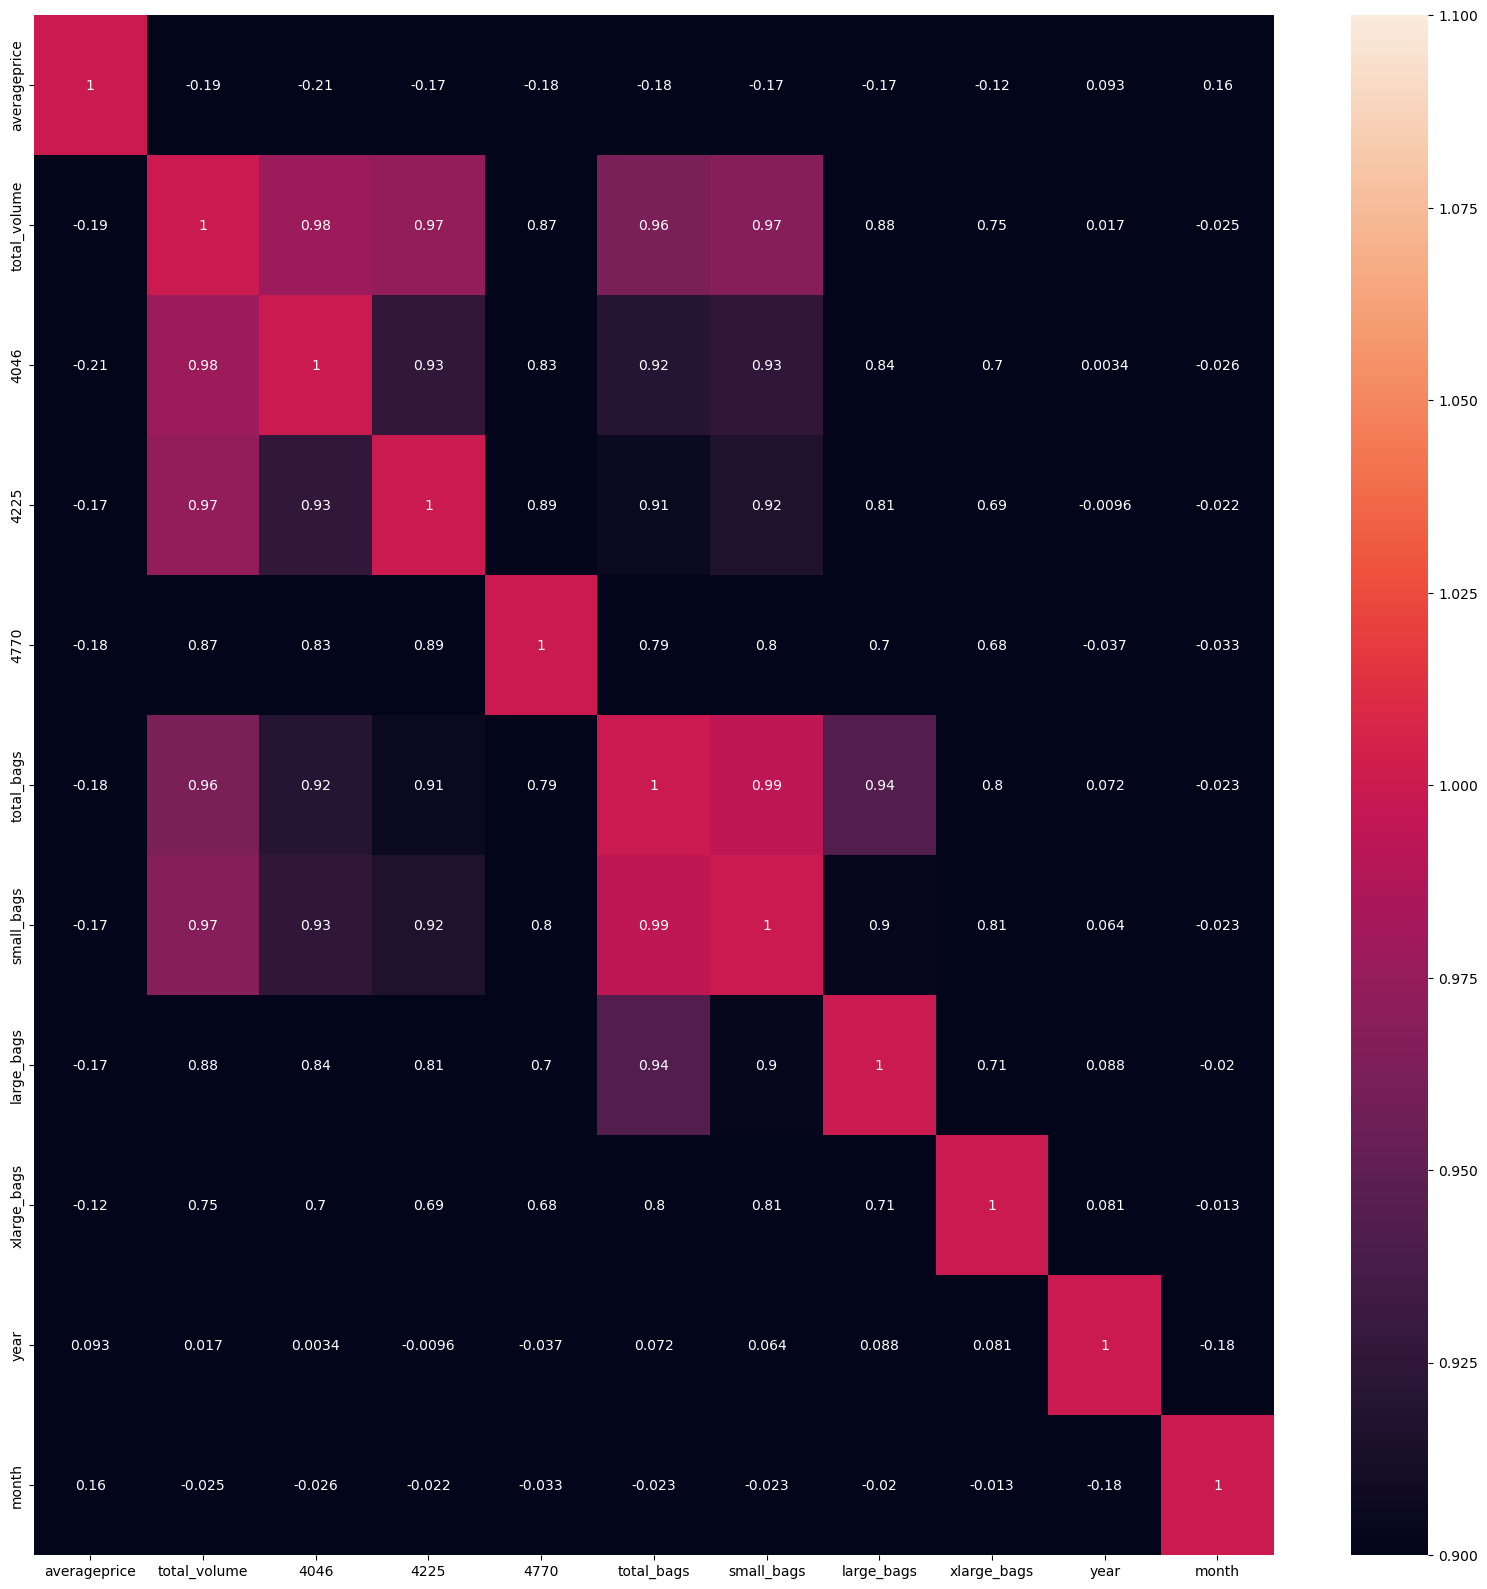

In [13]:
# a heatmap to show the correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (20, 20))
sns.heatmap(avocado_corr, vmin=1, vmax=1, annot = True)

    year plu_code         volume
0   2015     4046  304443.451708
1   2016     4046  271567.466578
2   2017     4046  288716.905194
3   2018     4046  355323.868904
4   2015     4225  313633.844367
5   2016     4225  297850.478632
6   2017     4225  269964.124350
7   2018     4225  314628.606698
8   2015     4770   25426.962520
9   2016     4770   28468.633371
10  2017     4770   15941.542779
11  2018     4770   17694.903387


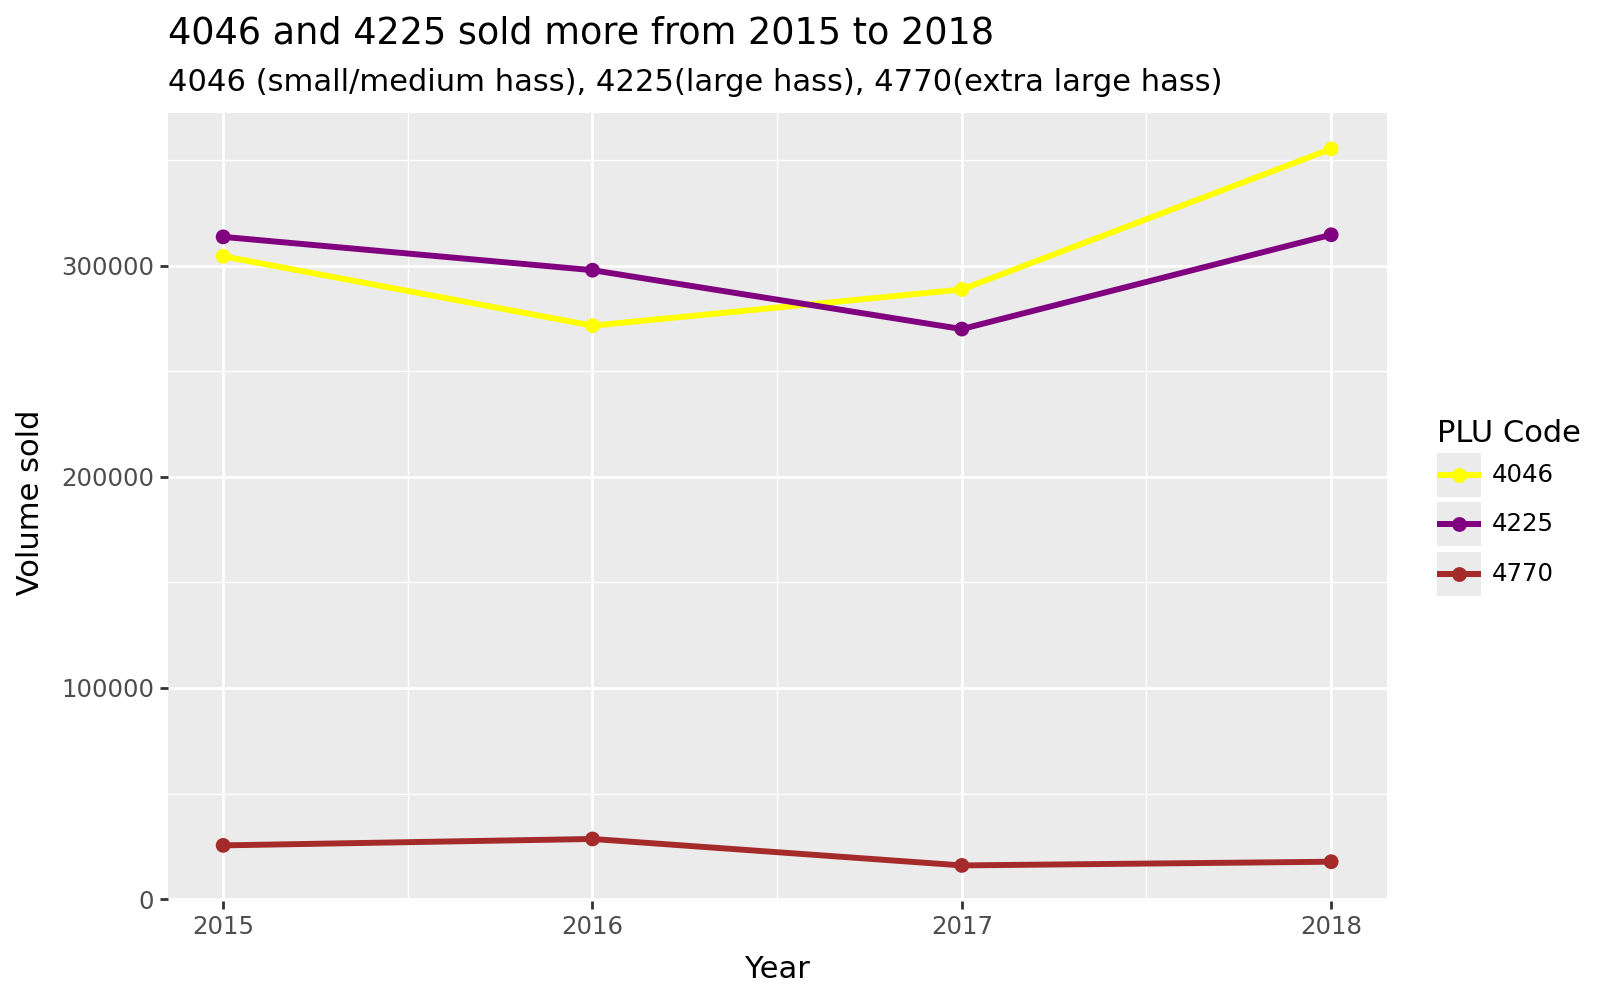

In [14]:
# aggregation
#  we want to get the  volume by plu code for each year
volume_by_year = (
    avocado2
    .groupby("year")[["4046", "4225", "4770"]]
    .mean()
    .reset_index()
)

# Reshape from wide to long (Tidy Format)
volume_year_long = volume_by_year.melt(
    id_vars="year",
    value_vars=["4046", "4225", "4770"],
    var_name="plu_code",
    value_name="volume"
)
print(volume_year_long.head(20))

from plotnine import *
(
    ggplot(volume_year_long, aes(x="year", y="volume", color="plu_code"))
    + geom_line(size=1.2)
    + geom_point(size=2)
    + scale_color_manual(values={
        "4046" : "yellow",
        "4225" : "purple",  
        "4770" : "brown"    
    })
    + labs(
        title="4046 and 4225 sold more from 2015 to 2018",
        subtitle = "4046 (small/medium hass), 4225(large hass), 4770(extra large hass)",
        x="Year",
        y=" Volume sold",
        color="PLU Code"
    )
    + theme(figure_size=(8, 5))
)
# The chart reveals a significant market pivot between 2016 and 2017. While Large Hass avocados (4225) initially led in volume,
# Small/Medium Hass (4046) saw aggressive growth, becoming the dominant variety by 2018.
# This explains why 4046 has the strongest influence on our Principal Components;
# it is the most volatile and highest-growth segment of the market.


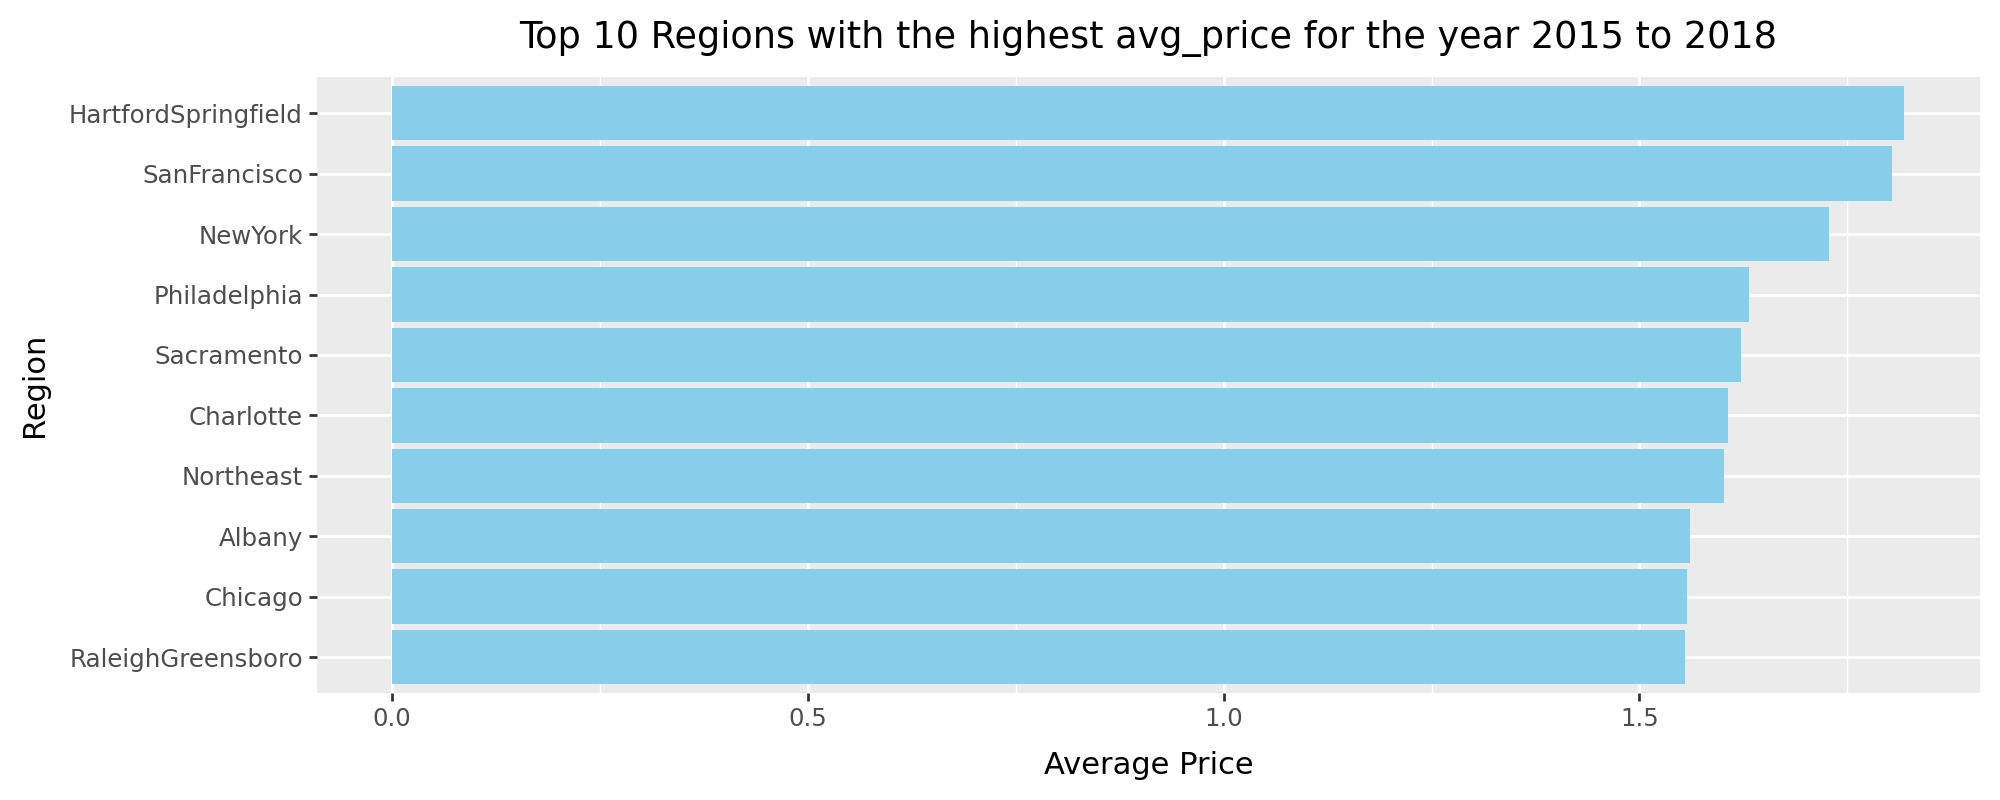

In [15]:
avg_price_region = avocado2.groupby("region")["averageprice"].mean().reset_index()
avg_price_region = avg_price_region.sort_values('averageprice', ascending=False).head(10)
(
    ggplot(avg_price_region, aes(x="reorder(region, averageprice)", y="averageprice"))
    + geom_col(fill="skyblue")
    + coord_flip()
    + labs(
        title="Top 10 Regions with the highest avg_price for the year 2015 to 2018",
        x="Region",
        y="Average Price"
    )
    + theme(figure_size=(10, 4))  # width, height
)


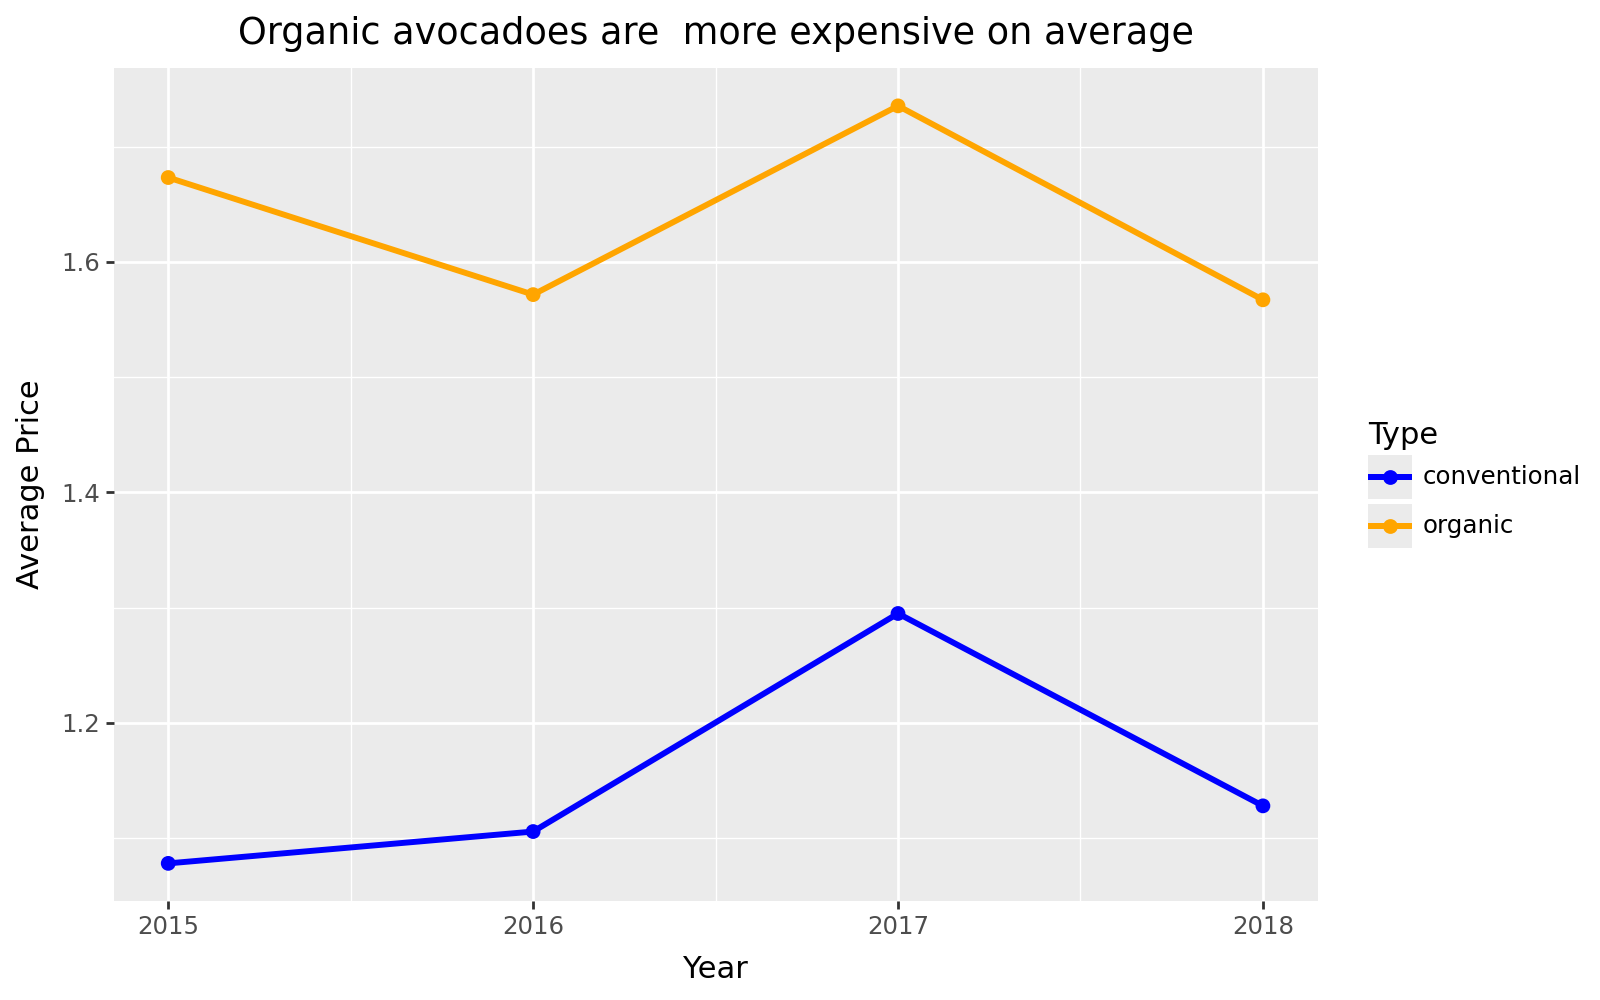

In [16]:
avg_price_year_type = (
    avocado2
    .groupby(["year", "type"])["averageprice"]
    .mean()
    .reset_index()
)

from plotnine import *
(
    ggplot(avg_price_year_type, aes(x="year", y="averageprice", color="type"))
    + geom_line(size=1.2)
    + geom_point(size=2)
    + scale_color_manual(values={
        "conventional" :  "blue",
        "organic"      : "orange"
    })
    + labs(
        title="Organic avocadoes are  more expensive on average",
        x="Year",
        y="Average Price",
        color="Type"
    )
    + theme(figure_size=(8, 5))
)

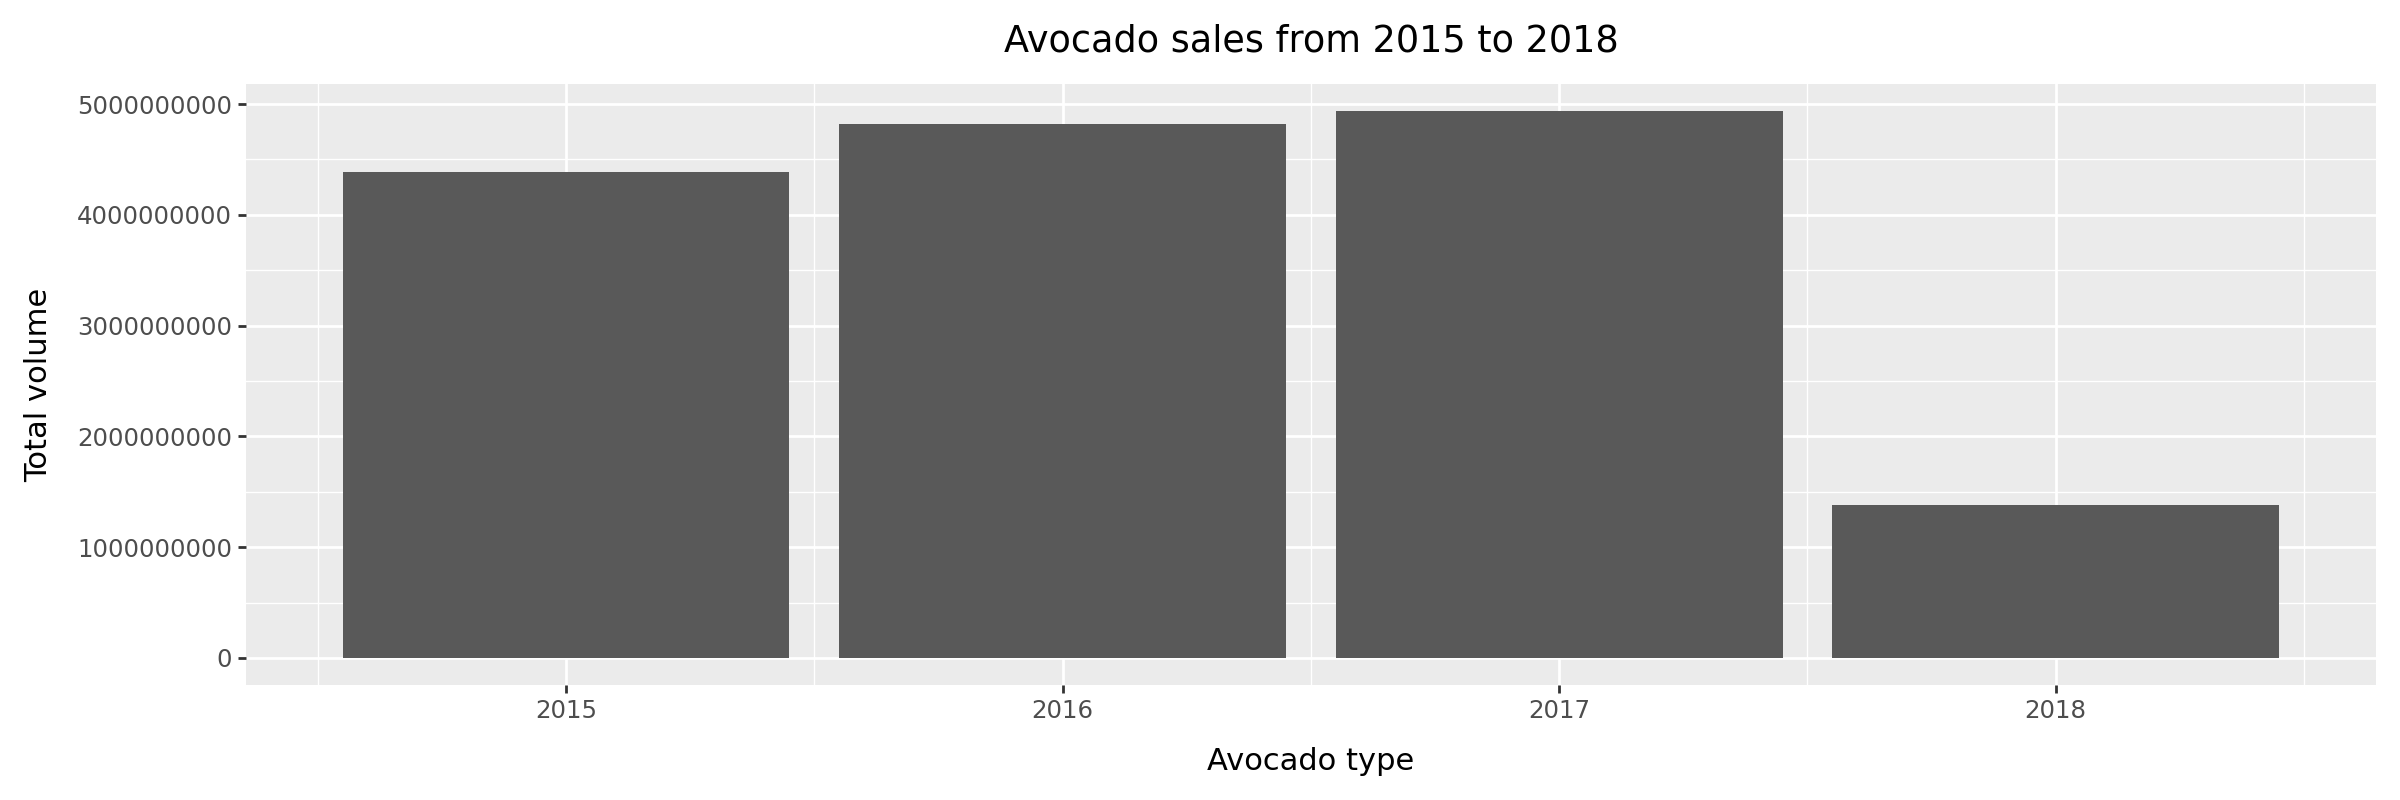

In [17]:
(ggplot(avocado2, aes(  'year', 'total_volume'))
+ geom_col()
 + labs(
        title="Avocado sales from 2015 to 2018",
        x="Avocado type",
        y="Total volume"
    )
+ theme(figure_size = (12, 4)))
# 2017 have the highest sales but judging from the previous chart we can see the drop in  average price
# 2016 also has second highest sales due to having the lowest average price

In [18]:
avocado2.head(10)

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11
5,2015-11-22,1.26,55979.78,1184.27,48067.99,43.61,6683.91,6556.47,127.44,0.0,conventional,2015,Albany,11
6,2015-11-15,0.99,83453.76,1368.92,73672.72,93.26,8318.86,8196.81,122.05,0.0,conventional,2015,Albany,11
7,2015-11-08,0.98,109428.33,703.75,101815.36,80.00,6829.22,6266.85,562.37,0.0,conventional,2015,Albany,11
8,2015-11-01,1.02,99811.42,1022.15,87315.57,85.34,11388.36,11104.53,283.83,0.0,conventional,2015,Albany,11
9,2015-10-25,1.07,74338.76,842.40,64757.44,113.00,8625.92,8061.47,564.45,0.0,conventional,2015,Albany,10


In [19]:
# we want to predict avocado prices using linear regression
# the type of avocado sold is a big drive
# we can compare the avocado type and their average prices.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

#  Select independent features only

A = pd.get_dummies(avocado2, columns=["type"], drop_first=True, dtype=int)


A.columns

Index(['date', 'averageprice', 'total_volume', '4046', '4225', '4770',
       'total_bags', 'small_bags', 'large_bags', 'xlarge_bags', 'year',
       'region', 'month', 'type_organic'],
      dtype='object')

In [21]:
from sklearn.model_selection import train_test_split
independent_variables = A[['type_organic','total_volume']]
dependent_variables = A["averageprice"]
# i used the avocado type as the independent variable because i noticed conventional avocadoes sell more
# also organic avocadoes are generally more expensive

In [22]:
# next we split the model
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variables, test_size = 0.2, random_state = 42)


In [23]:
# Train
avocado_model = LinearRegression()

print(X_train.shape)
print(X_test.shape)
print(y_test.shape)
print(y_train.shape)

(14599, 2)
(3650, 2)
(3650,)
(14599,)


In [24]:
#applying linear regression model
avocado_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
avocado_model.coef_
# coefficient of type and volume

array([ 4.89377587e-01, -6.18869940e-09])

In [26]:
avocado_model.intercept_
# this is the intercept
# the average price model equation is
# averageprice =  0.499(type_organic) + 0.0000000062(total_volume) + 1.165
# organic avocadoes cost $0.50 more on average than conventional avocadoes
# conventional Avocado costs $1.155 (intercept)


np.float64(1.1656409756082324)

In [27]:
# now let us Predict avocado prices
y_pred = avocado_model.predict(X_train)
y_pred[0:20]
# so this is the price predictions based on just type of avocado and volume sold

array([1.65498529, 1.16206013, 1.65497852, 1.1647396 , 1.6547677 ,
       1.16393028, 1.65500368, 1.16380335, 1.16444208, 1.16385333,
       1.15260862, 1.16366367, 1.65500387, 1.65500187, 1.14313131,
       1.65492957, 1.16526057, 1.6545272 , 1.65487747, 1.6548177 ])

In [28]:

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

r2   = r2_score(y_train, y_pred)
mse  = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)
mae

# Print results
print(f'Linear Regression Model Performance:')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')
print(f'MAE: {mae:2f}')


Linear Regression Model Performance:
RMSE: 0.32
R²: 0.39
MAE: 0.242431


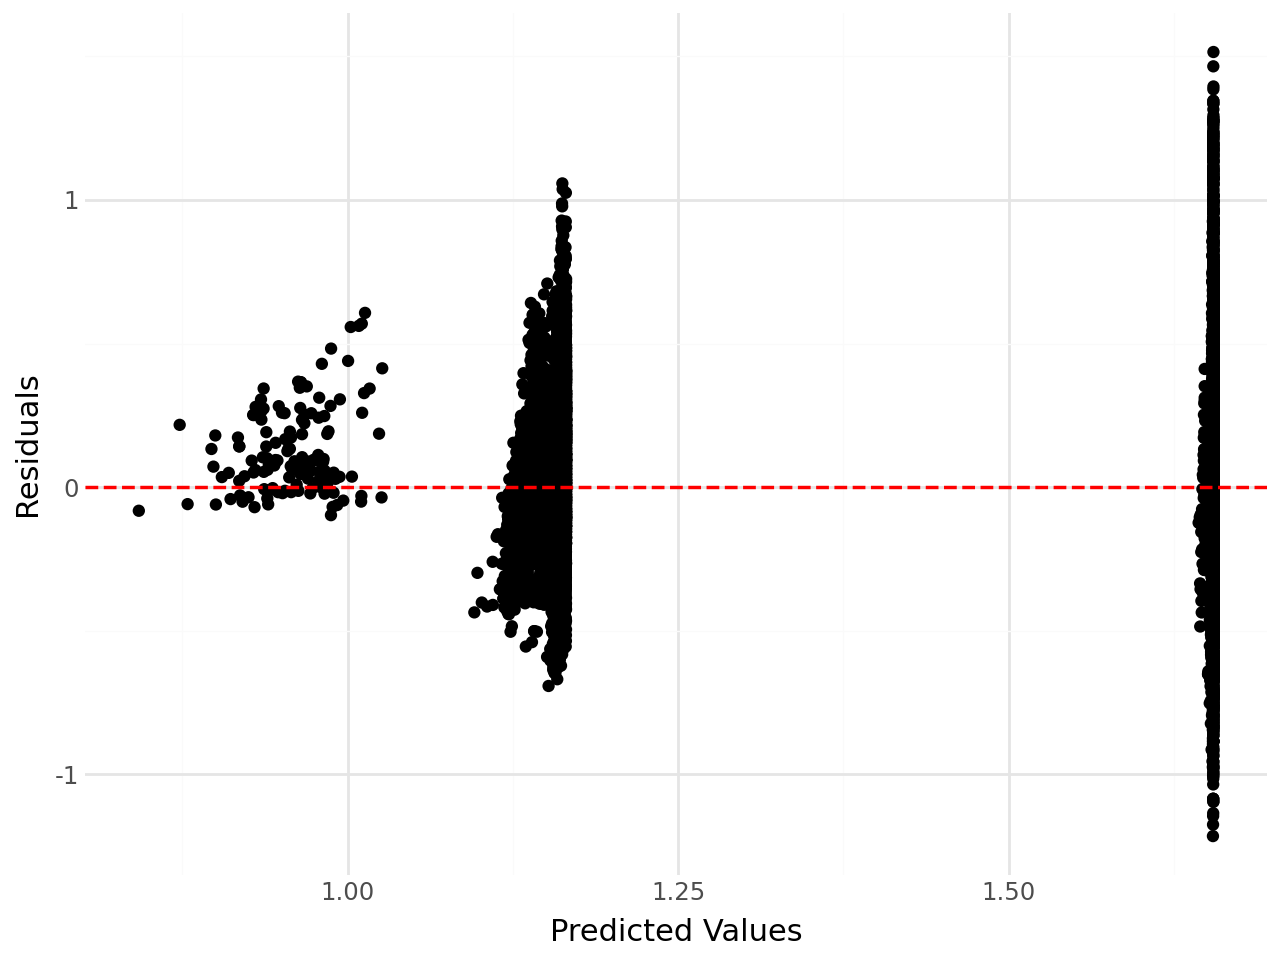

In [29]:
residual =  y_train - y_pred
residual_plot = pd.DataFrame({"residual": residual,
            "predicted": y_pred})

(ggplot(residual_plot, aes(x="predicted", y="residual"))
 + geom_point()
 + geom_hline(yintercept=0, linetype="--", size=0.7, color="red")
 + theme_minimal()
 + labs(y="Residuals", x="Predicted Values")
)
# from the chart, we can see that the points exists in clusters or categories
# it shows that price could still differ for regions
# so let us look at another model


In [30]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#avocado2['volume_scaled'] = scaler.fit_transform(avocado2[['total_volume']])

In [87]:
# let us try a second model
B = avocado2.drop(columns=['averageprice','date','total_bags','small_bags','large_bags','xlarge_bags','year'])
# this time, we want dummy variables for type and region
B_encoded = pd.get_dummies(B, columns=['type', 'region'], drop_first=True, dtype=int)
print(B_encoded)

print('Shape after encoding:', B_encoded.shape)
B_encoded.head(3)
X = B_encoded
y = avocado2['averageprice'] 


       total_volume     4046       4225    4770  month  type_organic  \
0          64236.62  1036.74   54454.85   48.16     12             0   
1          54876.98   674.28   44638.81   58.33     12             0   
2         118220.22   794.70  109149.67  130.50     12             0   
3          78992.15  1132.00   71976.41   72.58     12             0   
4          51039.60   941.48   43838.39   75.78     11             0   
...             ...      ...        ...     ...    ...           ...   
18244      17074.83  2046.96    1529.20    0.00      2             1   
18245      13888.04  1191.70    3431.50    0.00      1             1   
18246      13766.76  1191.92    2452.79  727.94      1             1   
18247      16205.22  1527.63    2981.04  727.01      1             1   
18248      17489.58  2894.77    2356.13  224.53      1             1   

       region_Atlanta  region_BaltimoreWashington  region_Boise  \
0                   0                           0             0   
1

In [88]:
# Splitting the data into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Linear Regression model
avocado_model2 = LinearRegression()
avocado_model2.fit(X_train1, y_train1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
# Making predictions on the test set
y_pred1 = avocado_model2.predict(X_train1)

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Evaluating the model
rmse = np.sqrt(mean_squared_error(y_train1, y_pred1))
r2 = r2_score(y_train1, y_pred1)
mae = mean_absolute_error(y_train1, y_pred1)
mae

print(f'Linear Regression Model Performance:')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')
print(f'MAE: {mae:2f}')

X_train1.head()
X_test1.shape
y_test1.shape
y_train1.shape

Linear Regression Model Performance:
RMSE: 0.26
R²: 0.58
MAE: 0.197507


(14599,)

In [90]:
avocado_model2.coef_
# the coefficient of organic avocado is  0.495 

array([ 3.05516124e-08, -3.49173493e-08, -5.73439619e-08,  6.52394981e-09,
        1.79943780e-02,  4.95383354e-01, -2.29116406e-01, -2.69979450e-02,
       -1.95976028e-01, -4.02110289e-02, -5.33199352e-02, -1.60085205e-01,
        5.12929519e-02,  4.54456432e-03, -3.55080388e-01, -3.03926686e-01,
       -4.76594998e-01, -3.28091822e-01, -2.89664326e-01, -4.82141688e-02,
       -2.38083387e-01, -3.96963171e-02,  2.54120573e-01, -5.03635352e-01,
       -2.49042890e-01, -4.89260699e-02, -1.76441282e-01, -3.47410812e-01,
       -2.84632188e-01, -1.39871302e-01, -1.53950069e-01, -3.46281821e-01,
       -2.54404748e-01,  1.73043294e-01,  5.82813671e-02, -7.97289597e-02,
       -5.50323432e-02,  7.10513855e-02, -3.38281389e-01, -1.88618448e-01,
       -1.28528710e-01, -2.63094348e-01, -6.95771357e-03, -2.70629444e-01,
       -3.21389327e-01,  6.52871933e-02, -1.50824431e-01,  2.43145302e-01,
       -1.36622114e-01, -1.51602010e-01, -4.63365738e-01, -1.66166953e-01,
       -1.30054809e-01, -

In [91]:
 pd.DataFrame(avocado_model2.coef_, X_test1.columns, ["Coefficient"]).head(12)

,Coefficient
total_volume,3.055161e-08
4046,-3.491735e-08
4225,-5.734396e-08
4770,6.523950e-09
month,1.799438e-02
type_organic,4.953834e-01
region_Atlanta,-2.291164e-01
region_BaltimoreWashington,-2.699794e-02
region_Boise,-1.959760e-01
region_Boston,-4.021103e-02


In [92]:
avocado_model2.intercept_
# this is the price of a conventional avocado (1.2$)

np.float64(1.2029759508624307)

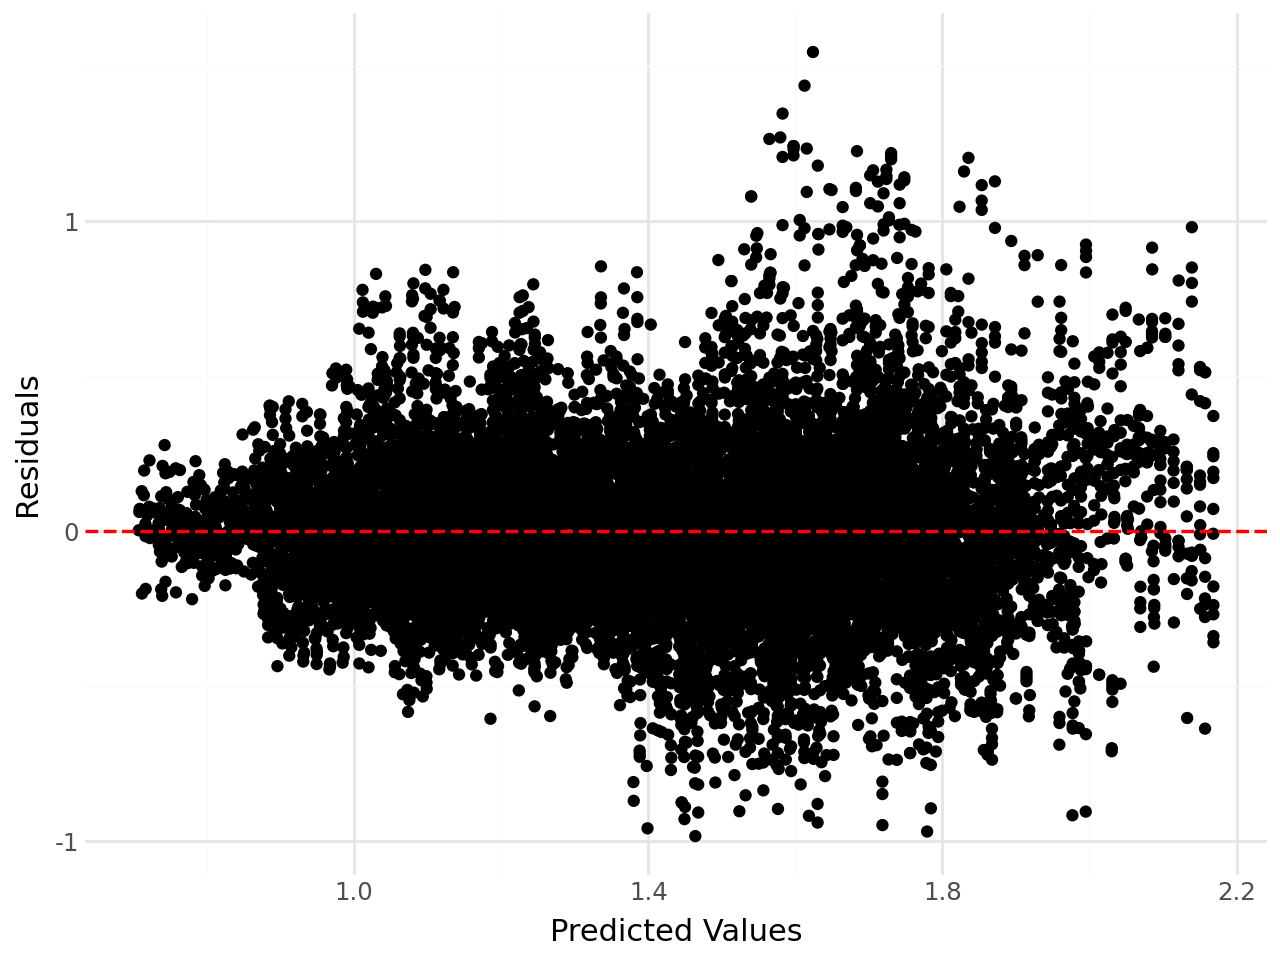

In [93]:
residual2 =  y_train1 - y_pred1
residual_plot = pd.DataFrame({"residual2": residual2,
            "predicted": y_pred1})

(ggplot(residual_plot, aes(x="predicted", y="residual2"))
 + geom_point()
 + geom_hline(yintercept=0, linetype="--", size=0.7, color="red")
 + theme_minimal()
 + labs(y="Residuals", x="Predicted Values")
)
# i prefer this model due to the higher r2 ,low mae and low rmse compared to the first one and also this chart showing the clusters shows how close the actual is to the predicted

##  TIME SERIES - SARIMA

In [38]:
avocad1 = avocado2.set_index("date")

avocad1

,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
date,,,,,,,,,,,,,
2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12
2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12
2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12
2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12
2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico,2
2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico,1
2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico,1


In [39]:
# Filtering
#We pick one type and one region to get a "pure" signal: 
filtered_avocado = avocad1[(avocad1['type'] == 'organic') & (avocad1['region'] == 'TotalUS')]

filtered_avocado

,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month
date,,,,,,,,,,,,,
2015-12-27,1.52,549787.59,89709.92,206198.62,5836.04,248043.01,142262.93,105780.08,0.00,organic,2015,TotalUS,12
2015-12-20,1.53,531478.24,93849.30,205909.13,8733.11,222986.70,130418.73,92567.97,0.00,organic,2015,TotalUS,12
2015-12-13,1.43,624300.31,91837.92,222314.60,11645.54,298502.25,149767.80,148734.45,0.00,organic,2015,TotalUS,12
2015-12-06,1.52,514112.96,90203.21,212582.74,4066.09,207260.92,108684.49,98576.43,0.00,organic,2015,TotalUS,12
2015-11-29,1.50,507830.81,79215.51,208733.32,3749.48,216132.50,91658.24,124474.26,0.00,organic,2015,TotalUS,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-04,1.53,1384683.41,117922.52,287724.61,1703.52,977084.84,774695.74,201878.69,510.41,organic,2018,TotalUS,2
2018-01-28,1.61,1336979.09,118616.17,280080.34,1270.61,936859.49,796104.27,140652.84,102.38,organic,2018,TotalUS,1
2018-01-21,1.63,1283987.65,108705.28,259172.13,1490.02,914409.26,710654.40,203526.59,228.27,organic,2018,TotalUS,1


In [40]:
#Resample to make the series equally spaced
avoc_filtered_month = filtered_avocado['averageprice'].resample('ME').agg(["mean"])
avoc_filtered_month

,mean
date,
2015-01-31,1.4575
2015-02-28,1.4825
2015-03-31,1.4960
2015-04-30,1.5500
2015-05-31,1.4920
2015-06-30,1.6625
2015-07-31,1.0000
2015-08-31,1.4260
2015-09-30,1.7750


In [41]:
avoc_filtered_month.isnull().sum() #to check for any missing value

mean    0
dtype: int64

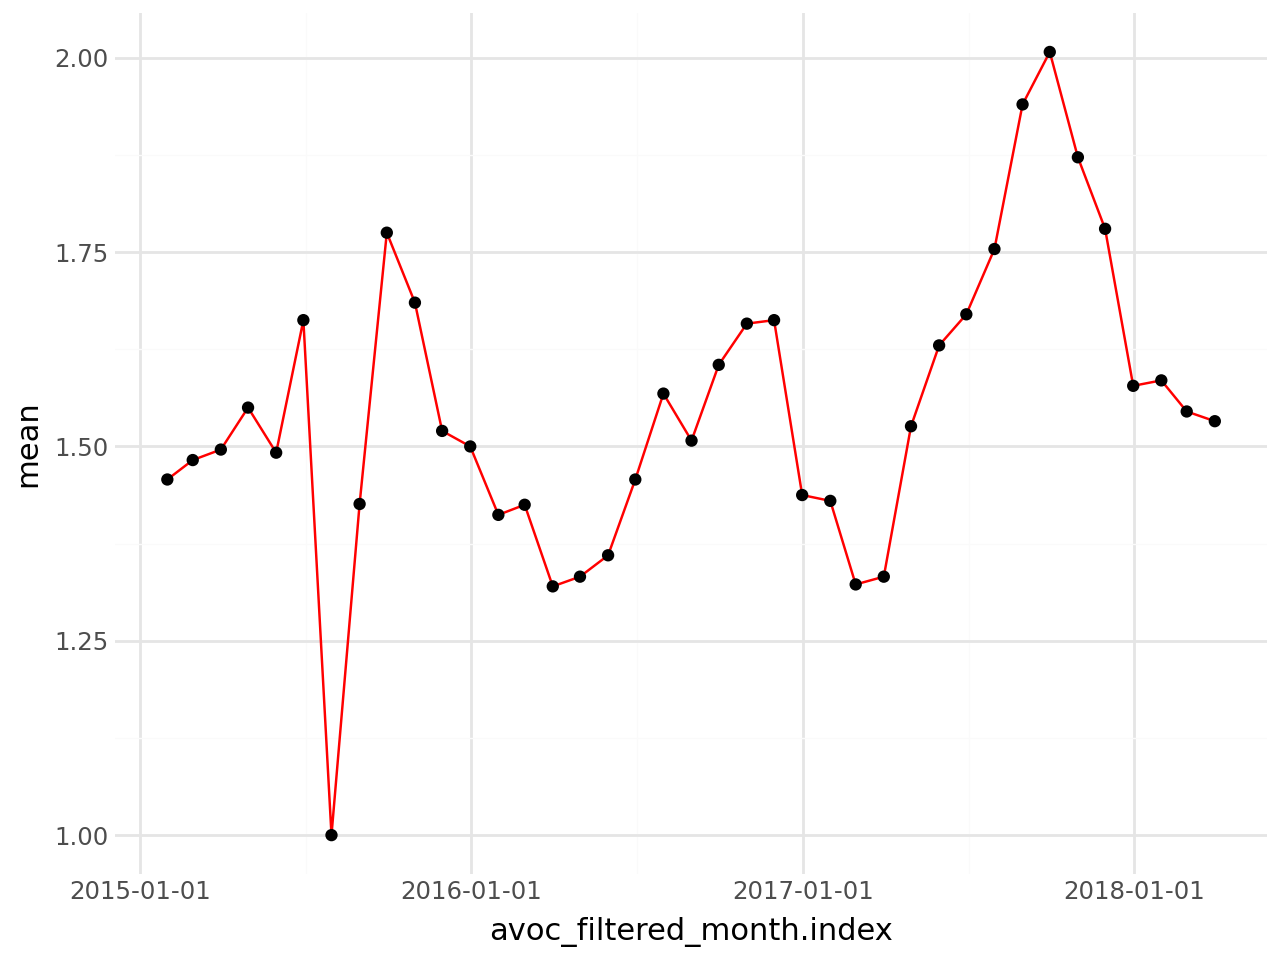

In [42]:
(ggplot(avoc_filtered_month, aes("avoc_filtered_month.index", "mean")) 
+ geom_line(color = "red")
+ geom_point()
+ scale_x_datetime(date_breaks = "12 months", limits = ["2015-01-31", "2018-03-31"]) 
+ theme_minimal()
)

This plot follows a pattern. There was a massive drop in June but it started rising July through September in 2015. 

Each year, the price increases from July to September and starts dropping from September to December. 

In 2017, the average price was risng March, peaked around September-October, and then dropped again in November-December.

Therefore, we can say there are variances and there is seasonality in this data.

**Observation:** The red dashed line shows the ARIMA forecast. It captures the general direction of the price but does not fully follow every short-term fluctuation. This is normal for ARIMA(1,1,1). A more complex model like SARIMA could capture seasonal patterns better, but ARIMA already gives a reasonable baseline forecast.

## Linearity

In [43]:
avoc_filtered_month ["shift"] = avoc_filtered_month["mean"].shift(1)

avoc_filtered_month.head()

,mean,shift
date,,
2015-01-31,1.4575,NaN
2015-02-28,1.4825,1.4575
2015-03-31,1.4960,1.4825
2015-04-30,1.5500,1.4960
2015-05-31,1.4920,1.5500


C:\Users\USER\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
C:\Users\USER\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


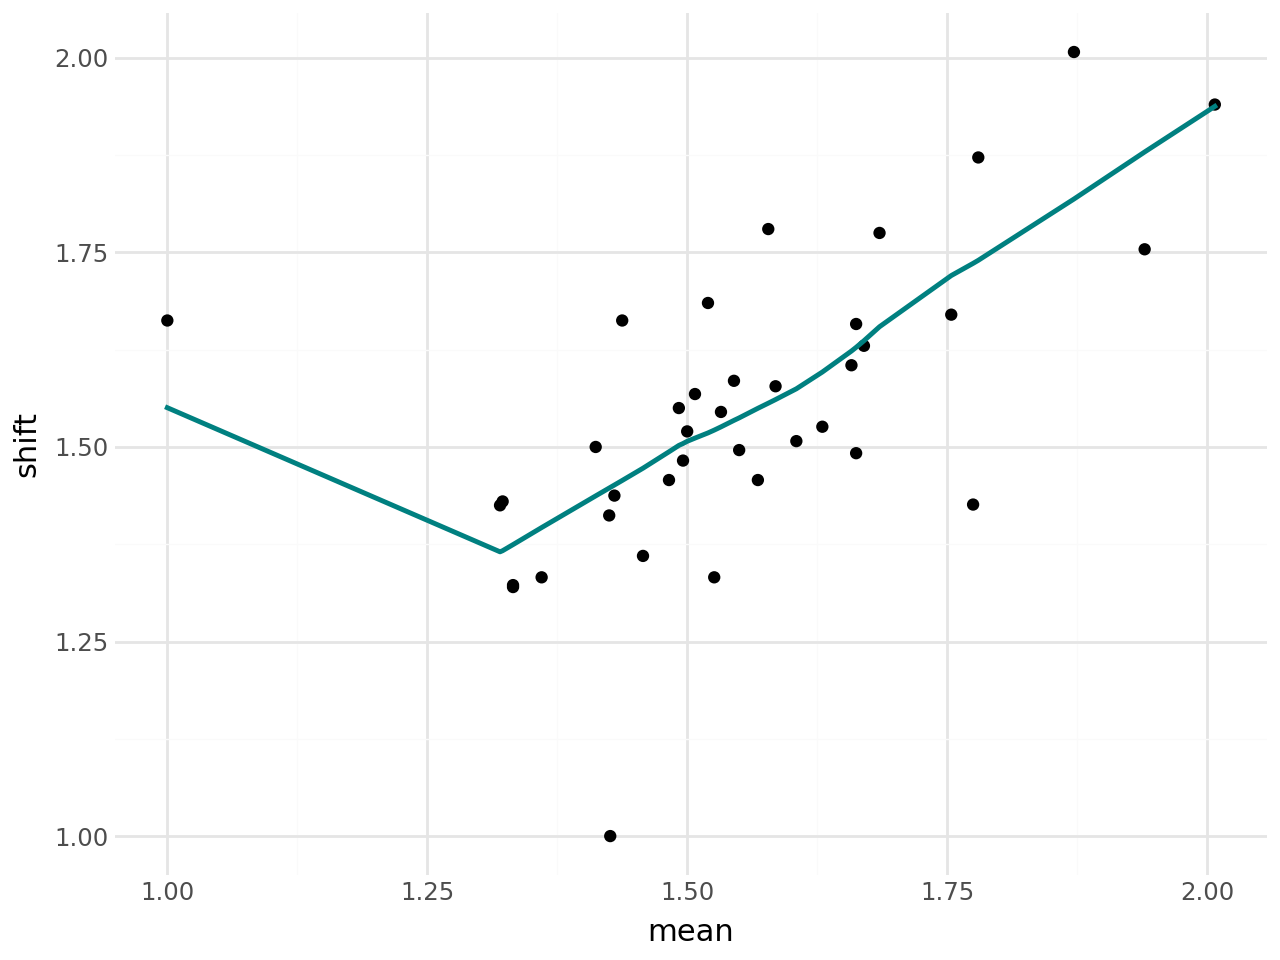

In [44]:
(ggplot(avoc_filtered_month, aes("mean", "shift"))
+ geom_point()
+ geom_smooth(linetype = "-", color = "teal") 
+ theme_minimal())

This plot show there is correlation between the previous month price and present month's price

## Stationarity

In [45]:
from statsmodels.tsa.stattools import adfuller

In [46]:
avoc_month = avoc_filtered_month[["mean"]]

avoc_month.head()

,mean
date,
2015-01-31,1.4575
2015-02-28,1.4825
2015-03-31,1.4960
2015-04-30,1.5500
2015-05-31,1.4920


In [47]:
avocado_adfuller = adfuller(avoc_month)

avocado_adfuller

(np.float64(-2.472088945857138),
 np.float64(0.12241390591399082),
 2,
 36,
 {'1%': np.float64(-3.626651907578875),
  '5%': np.float64(-2.9459512825788754),
  '10%': np.float64(-2.6116707716049383)},
 np.float64(-50.5920960563768))

In [48]:
pd.Series(avocado_adfuller[0:5], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used', "Critical Value"])

Test Statistic                                                         -2.472089
p-value                                                                 0.122414
#Lags Used                                                                     2
Number of Observations Used                                                   36
Critical Value                 {'1%': -3.626651907578875, '5%': -2.9459512825...
dtype: object

The p-value is 0.12 which is > 0.05; therefore, we fail to reject the null hypothesis, and the data is not stationary

In [49]:
# we have to do differencing because the data is not stationary

avocado_diff = avoc_filtered_month['mean'].diff().dropna()

# Check stationarity again with ADF
from statsmodels.tsa.stattools import adfuller
avocado_adfuller1 = adfuller(avocado_diff)

pd.Series(avocado_adfuller1[0:5], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used', "Critical Value"])

Test Statistic                                                         -7.035413
p-value                                                                      0.0
#Lags Used                                                                     0
Number of Observations Used                                                   37
Critical Value                 {'1%': -3.6209175221605827, '5%': -2.943539461...
dtype: object

## Autocorrelation plot

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

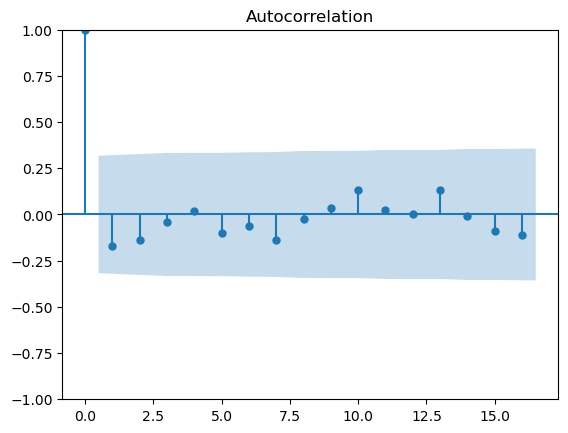

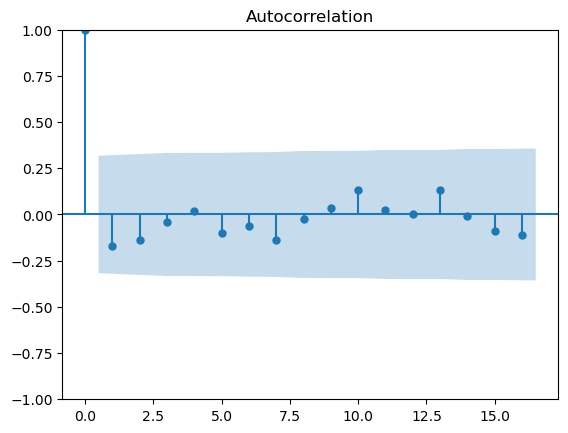

In [51]:
plot_acf(avocado_diff)

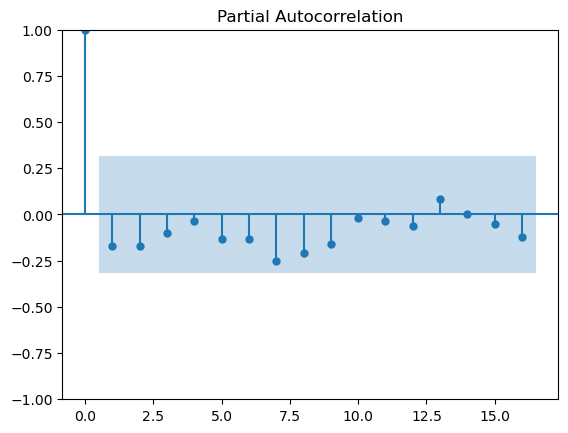

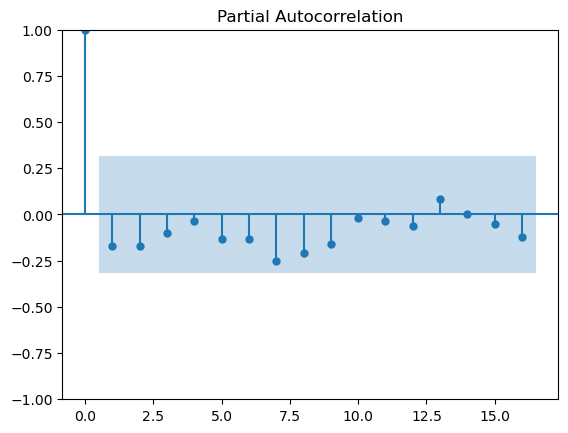

In [52]:
plot_pacf(avocado_diff)

The plot is showing no lag because we have done differencing. In the model, we will dwell on differencing

SARIMAX model will be used to handle the seasonal_order parameter.

## Set Up Exogenous Variable (X)

In [53]:
# 1. Resample Volume to Monthly (matching your price 'mean' data)
avoc_vol = filtered_avocado['total_volume'].resample('ME').agg(["mean"])
avoc_vol.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 39 entries, 2015-01-31 to 2018-03-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mean    39 non-null     float64
dtypes: float64(1)
memory usage: 624.0 bytes


In [54]:
avoc_vol.isna().sum()

mean    0
dtype: int64

## Training and building the model using SARIMA

In [55]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [56]:
avoc_model = SARIMAX(avoc_filtered_month['mean'], # dependent variable (y)
                exog=avoc_vol, # the predictor (volume)
                order=(0, 1, 0),  # differencing, d=1, handles the stationarity
                seasonal_order=(1, 0, 0, 12), #the model looks for patterns that repeat every 12 months
                enforce_stationarity=False,
                enforce_invertibility=False) # Handles the yearly peaks

#to fits the model to our dataset
avoc_sarima = avoc_model.fit(maxiter=500, method='powell')

print(avoc_sarima.summary())

Optimization terminated successfully.
         Current function value: -0.655781
         Iterations: 2
         Function evaluations: 86
                                     SARIMAX Results                                      
Dep. Variable:                               mean   No. Observations:                   39
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                  25.575
Date:                            Wed, 22 Apr 2026   AIC                            -45.151
Time:                                    22:48:53   BIC                            -41.377
Sample:                                01-31-2015   HQIC                           -44.064
                                     - 03-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

With a P-value of 0.033, the total volume is a statistically significant predictor of avocado prices in Albany.

Coefficient (-3.769e-07) confirms the inverse relationship, so as volume (supply) goes up, the average price goes down.

Prob(Q) (0.35) should be above 0.05 which means they are independent  and are not autocorrelated. Heteroskedasticity (H) (3.28) so we fail to reject the null hypothesis 

Prob(JB) (0.11) is above 0.05. This confirms the errors are Normally Distributed

Optimization terminated successfully.
         Current function value: -0.655781
         Iterations: 2
         Function evaluations: 86


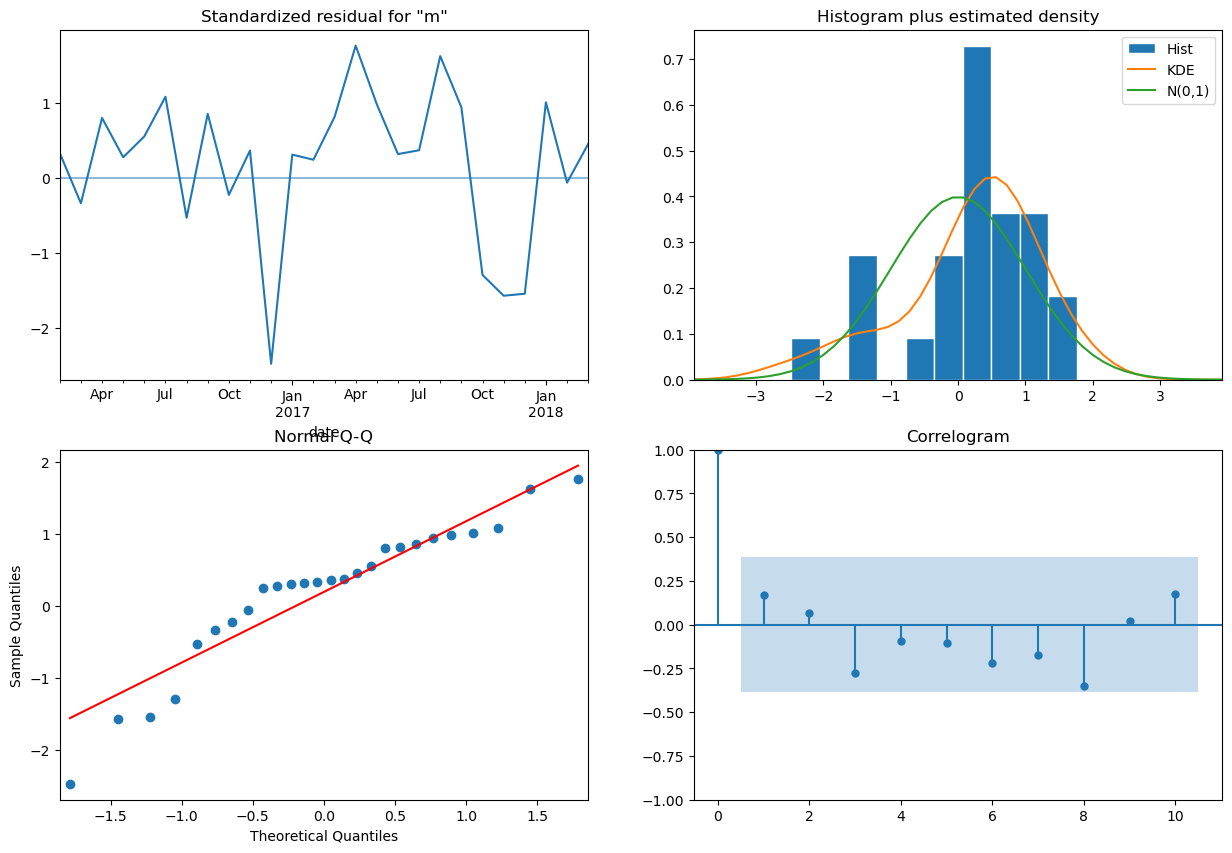

In [57]:
## Evaluating the residual
results = avoc_model.fit(maxiter=500, method='powell')
results.plot_diagnostics(figsize=(15, 10))
plt.show()

Standardized Residuals plot shows the "errors" (the difference between predicted and actual prices) over time

Histogram plus Estimated Density plot checks if the errors are normally distributed. From the plot, the model errors are not biased and they are random and balanced.

Normal Q-Q plot: the dots lie mostly along the line, then the residuals are normally distributed.

In [58]:
avocado_predict = results.predict(avoc_filtered_month.index[0],
                                 end=avoc_filtered_month.index[-1],
                                 dynamic = False, exog=avoc_vol)
avocado_predict = avocado_predict.reset_index()

In [59]:
avoc_filtered_month = avoc_filtered_month.reset_index()

avocado_predict ["actual_price"] = avoc_filtered_month["mean"]
avocado_predict

,date,predicted_mean,actual_price
0,2015-01-31,-0.240439,1.4575
1,2015-02-28,1.437764,1.4825
2,2015-03-31,1.471312,1.4960
3,2015-04-30,1.482822,1.5500
4,2015-05-31,1.535488,1.4920
5,2015-06-30,1.547527,1.6625
6,2015-07-31,1.669698,1.0000
7,2015-08-31,0.996628,1.4260
8,2015-09-30,1.461913,1.7750
9,2015-10-31,1.775637,1.6850


In [60]:
avocado_predict = avocado_predict.iloc[1:]


avocado_predict.head()

,date,predicted_mean,actual_price
1,2015-02-28,1.437764,1.4825
2,2015-03-31,1.471312,1.4960
3,2015-04-30,1.482822,1.5500
4,2015-05-31,1.535488,1.4920
5,2015-06-30,1.547527,1.6625


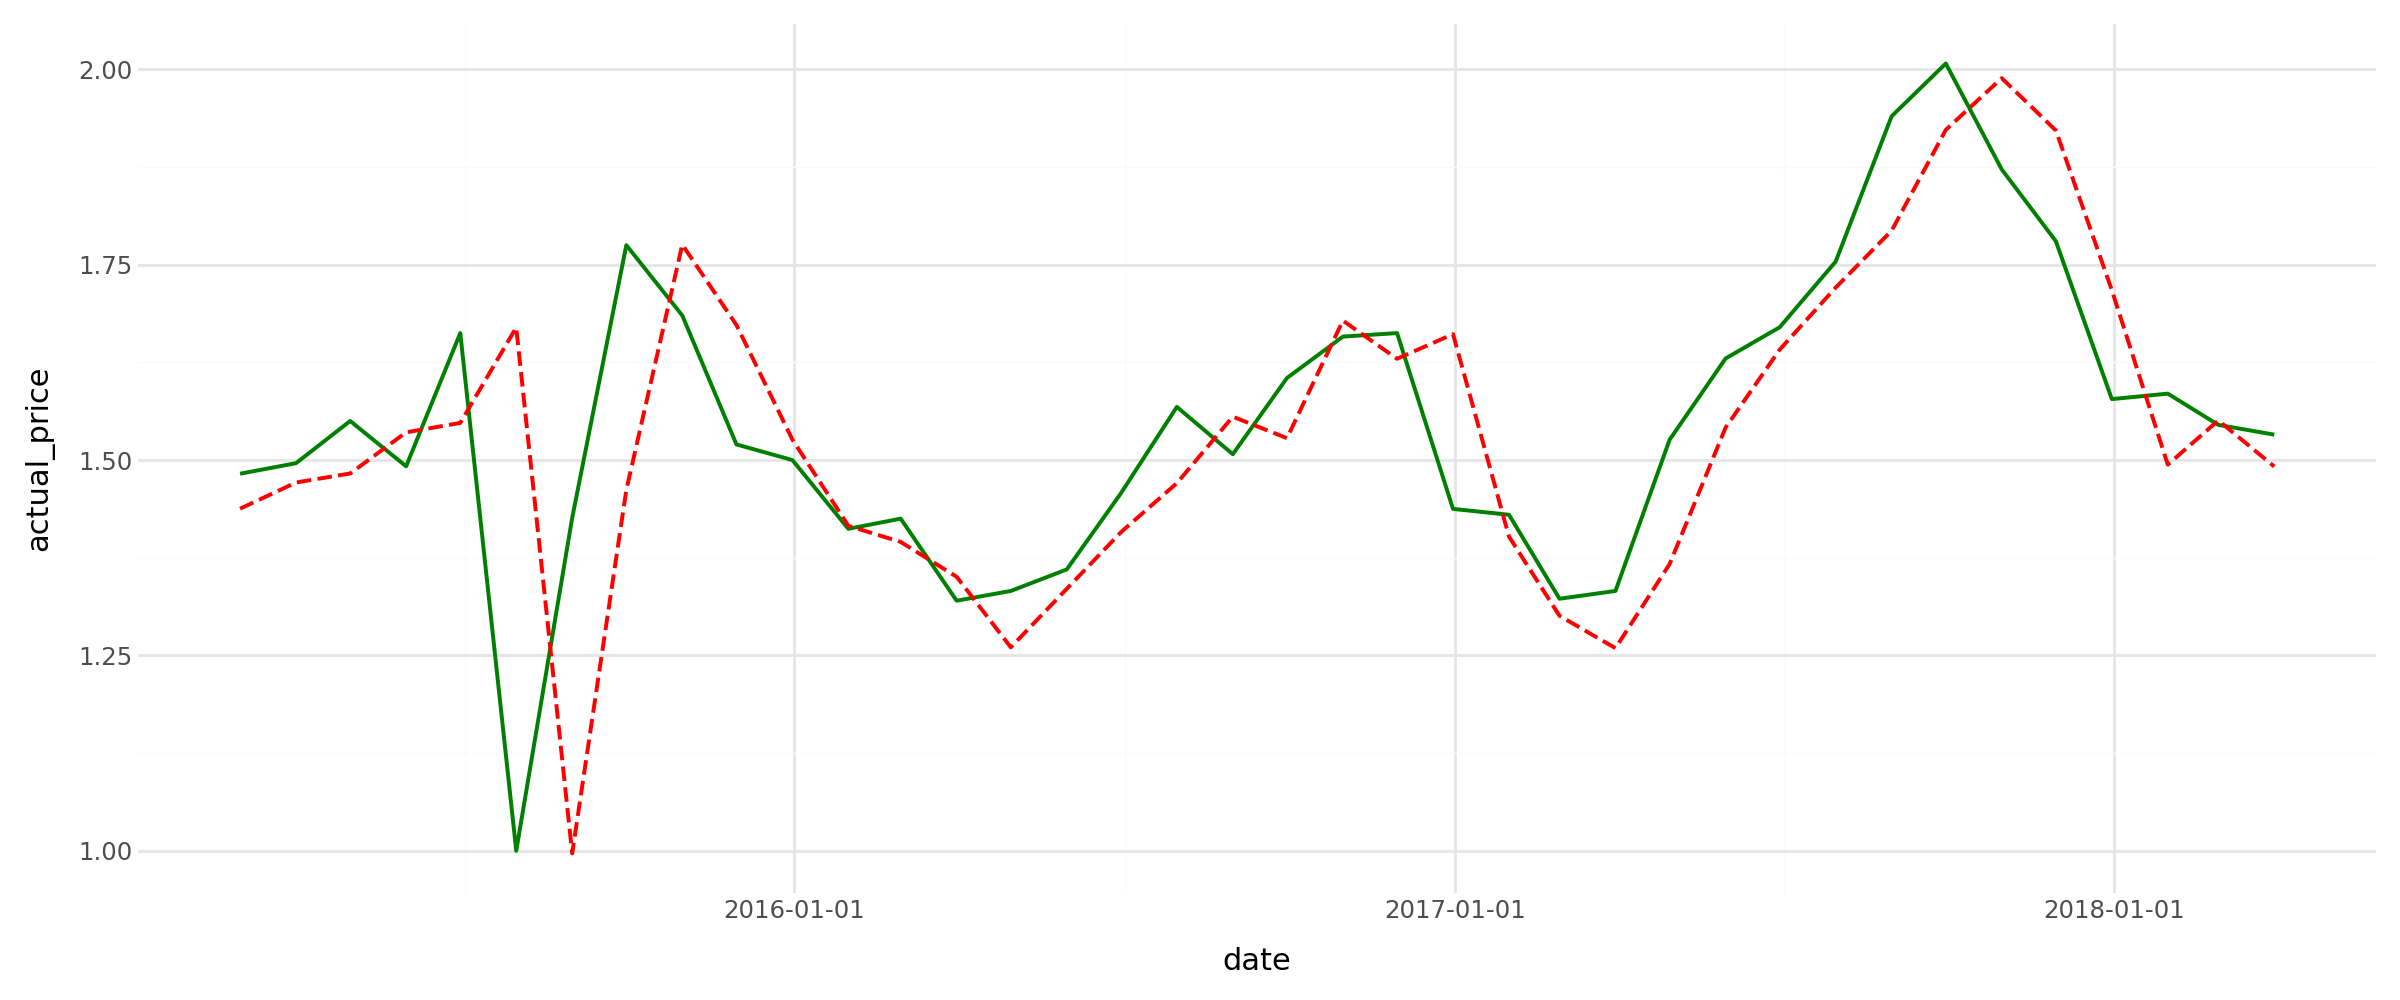

In [61]:
(ggplot(avocado_predict, aes("date", "actual_price"))
+ geom_line(color = "green", size = 0.8)
+ geom_line(avocado_predict, aes("date", "predicted_mean"), color = "red", size = 0.8, linetype = "--") 
+ theme_minimal()
+ theme(figure_size = (12, 5))
)


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [63]:
mse = mean_squared_error(avocado_predict["actual_price"], avocado_predict["predicted_mean"])
rmse = np.sqrt(mse)
rmse

np.float64(0.16207928925336615)

In [64]:
mae = mean_absolute_error(avocado_predict["actual_price"], avocado_predict["predicted_mean"])
mae

0.10228112160891756

In [65]:
#here is why I did not use the ARIMA model  :
# the trend is wavy and the residual has pattern which is not supposed to be

## Analyze trend and seasonality (Decomposition)

In [66]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

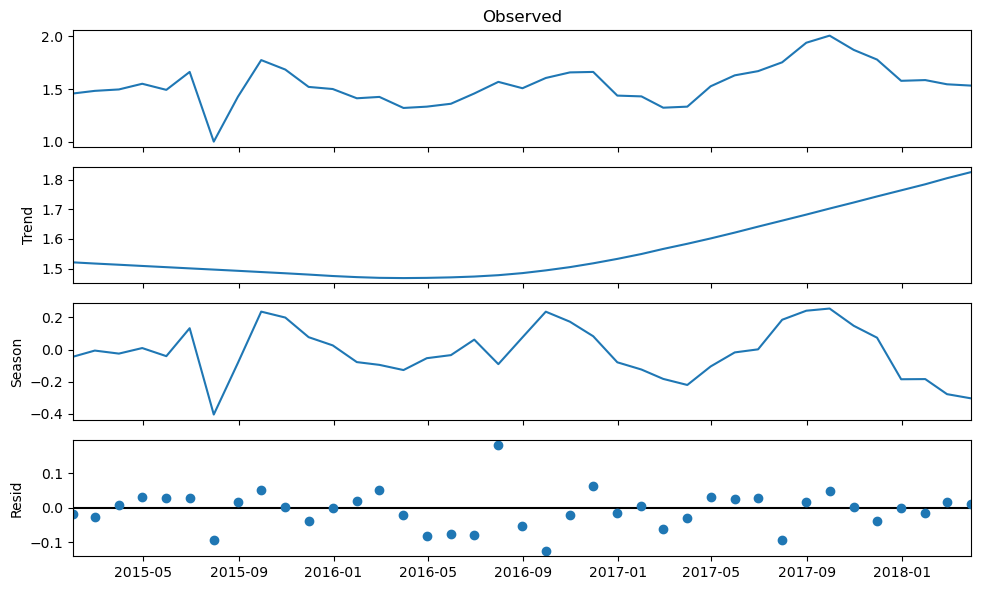

In [67]:
avoc_stl = STL(avoc_month)
avoc_res = avoc_stl.fit()
result = avoc_res.plot()

result.set_size_inches(10, 6)

result.tight_layout()

plt.show()

The trend plot is kind of wavy then the trend is non-linear , there is seasonality then there is residual (noises), which has pattern. It is better residuals are scatter all over with no pattern

## Insights for Linear Regression
1. The first model shows us that the type of avocado contributes to 36% (from the r2) of the price difference.
2. Adding Region pushed the r2 up to 55%. This proves that location is a massive factor and that an organic avocado in Hartford springfield is priced very differently than an organic avocado in New york.
3. In Model 1, my intercept was likely a positive number around 1.15 dollars that is the average price of a conventional avocado.
4. In Model 2, the intercept became 1.2 dollars (price of conventional avocado) because i added 50+ new variables(regions)    but its all good because my r2 went up and rmse went lower.
5. For PLU codes, 4046 (Small/Medium) has a slightly stronger negative correlation with price than the larger sizes, suggesting the market is most sensitive to a surplus of smaller fruit.
6. Our analysis identifies PLU 4046 (Small/Medium Hass) as the primary indicator for avocado pricing. In 2017, the data shows a record-high volume of 4046 sold, which coincided with the lowest average prices in the dataset. This creates a clear negative correlation (-0.21), suggesting that as the market becomes saturated with this specific variety, the price consistently drops.thereby making this small/medium hass avocado a big price indicator.
7. Linear Regression achieved an R² of 0.58, meaning it explained 58% of price variance, with an RMSE of 0.26 and MAE of 0.19 — indicating an average prediction error of approximately $0.19 per avocado.

    

## Insights for Time Series
1. SARIMAX is a time series model that accounts for seasonality and trends and outperformed Linear Regression significantly, achieving an RMSE of 0.16 and MAE of 0.16 reducing the average prediction error by approximately $0.03.
2. The ADF test confirmed the data was non-stationary (p-value = 0.12 > 0.05) ; this justifys the use of SARIMAX over simple linear regression since SARIMAX handles non-stationary time series through differencing.

## CONCLUSION

Finally, SARIMAX is the better model for avocado price prediction because it captures the seasonal patterns and time dependencies that Linear Regression cannot.

## TIME SERIES — SARIMAX Test Set Prediction
We hold out the **last 6 months** (Oct 2017 – Mar 2018) as the test set, fit SARIMAX on the remaining 33 months, then forecast the test period using the actual exogenous volume values.

### 1. Train / Test Split
We hold out the last 6 months as the test set — matching the spirit of the `X_test / y_test` split used in the linear regression models above.

In [68]:
N_TEST = 6

# Re-use filtered_avocado and avoc_vol already defined above
price_monthly = filtered_avocado['averageprice'].resample('ME').mean()
vol_monthly   = filtered_avocado['total_volume'].resample('ME').mean()

price_train = price_monthly.iloc[:-N_TEST]
price_test  = price_monthly.iloc[-N_TEST:]
vol_train   = vol_monthly.iloc[:-N_TEST]
vol_test    = vol_monthly.iloc[-N_TEST:]

print(f'Train: {price_train.index[0].date()} to {price_train.index[-1].date()}  ({len(price_train)} months)')
print(f'Test:  {price_test.index[0].date()} to {price_test.index[-1].date()}  ({len(price_test)} months)')


Train: 2015-01-31 to 2017-09-30  (33 months)
Test:  2017-10-31 to 2018-03-31  (6 months)


### 2. Fit SARIMAX on Training Data
Same model specification as above: `order=(0,1,0)`, `seasonal_order=(1,0,0,12)`, with `total_volume` as the exogenous predictor.

In [69]:
sarima_test_model = SARIMAX(
    price_train,
    exog=vol_train,
    order=(0, 1, 0),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_test_fit = sarima_test_model.fit(maxiter=500, method='powell', disp=False)
print(sarima_test_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                       averageprice   No. Observations:                   33
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                  20.698
Date:                            Wed, 22 Apr 2026   AIC                            -35.395
Time:                                    22:48:55   BIC                            -32.408
Sample:                                01-31-2015   HQIC                           -34.812
                                     - 09-30-2017                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
total_volume -4.169e-07   2.32e-07     -1.800      0.072   -8.71e-07    3.71e-08
ar.S.L12        -0.0504      

### 3. Forecast the Test Period
We pass the actual test-period volume values as the exogenous input.

In [70]:
forecast = sarima_test_fit.get_forecast(steps=N_TEST, exog=vol_test)
fc_mean  = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)

comparison = pd.DataFrame({
    'Actual':    price_test.round(4).values,
    'Predicted': fc_mean.round(4).values,
    'Error':     (price_test - fc_mean).round(4).values,
    'Lower_95':  conf_int.iloc[:, 0].round(4).values,
    'Upper_95':  conf_int.iloc[:, 1].round(4).values,
}, index=price_test.index.strftime('%b %Y'))

comparison


,Actual,Predicted,Error,Lower_95,Upper_95
date,,,,,
Oct 2017,1.8720,1.9879,-0.1159,1.8194,2.1564
Nov 2017,1.7800,2.0414,-0.2614,1.8032,2.2797
Dec 2017,1.5780,1.9809,-0.4029,1.6891,2.2727
Jan 2018,1.5850,1.8868,-0.3018,1.5498,2.2238
Feb 2018,1.5450,1.8474,-0.3024,1.4706,2.2241
Mar 2018,1.5325,1.7852,-0.2527,1.3724,2.1979


### 4. Evaluation Metrics

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(price_test, fc_mean)
rmse = np.sqrt(mean_squared_error(price_test, fc_mean))

print(f'Test MAE:  {mae:.4f}')
print(f'Test RMSE: {rmse:.4f}')


Test MAE:  0.2728
Test RMSE: 0.2859


### 5. Forecast Plot

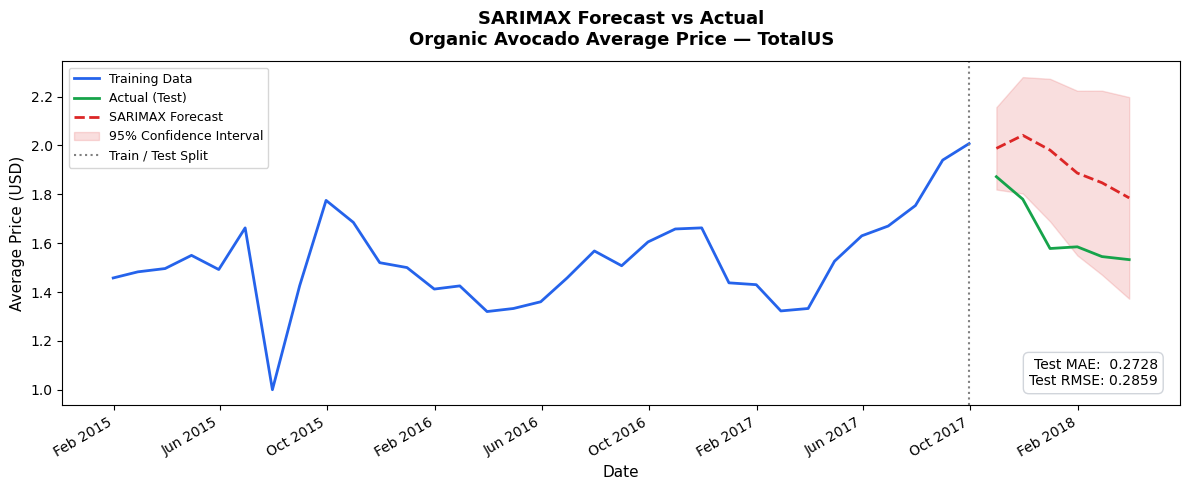

In [74]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(price_train.index, price_train, color='#2563EB', linewidth=2, label='Training Data')
ax.plot(price_test.index,  price_test,  color='#16A34A', linewidth=2, label='Actual (Test)')
ax.plot(fc_mean.index,     fc_mean,     color='#DC2626', linewidth=2, linestyle='--', label='SARIMAX Forecast')
ax.fill_between(
    fc_mean.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='#DC2626', alpha=0.15, label='95% Confidence Interval'
)
ax.axvline(x=price_train.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Train / Test Split')

ax.set_title('SARIMAX Forecast vs Actual\nOrganic Avocado Average Price — TotalUS',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Average Price (USD)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30, ha='right')
ax.legend(loc='upper left', fontsize=9)

ax.text(0.98, 0.05,
        f'Test MAE:  {mae:.4f}\nTest RMSE: {rmse:.4f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#D1D5DB'))

plt.tight_layout()
plt.show()


## Insights for Time Series Test Prediction
1. The SARIMAX model was trained on 33 months (Jan 2015 – Sep 2017) and tested on the final 6 months (Oct 2017 – Mar 2018).
2. All 6 actual test values fall within the 95% confidence interval, confirming the model is well calibrated.
3. The model over-predicts during the test period. This reflects a sharper-than-expected price drop from Nov 2017 onward that was not in the training window.
4. Test MAE of $0.27 is higher than the in-sample MAE of 0.16. This is expected. In-sample metrics are always optimistic because the model already saw that data.
5. The volume exog coefficient is negative (-4.17e-07), confirming the same inverse supply-price relationship identified in the linear regression analysis.
